# Embedding-based Lung Cancer Classification

In this notebook, we'll explore to ways to use embeddings to classify lung cancer (NSCLC) subtypes, specifically lung adenocarcinoma vs lung squamous cell carcinoma:
* We'll use cases from TCGA as training data and cases from CPTAC as evaluation data.
* We'll implement classifiers over embeddings derived from either gene expression (RNAseq) or histopathology (WSI) data.
* We'll explore two model types: logistic regression (LR) and k-nearest neighbors (kNN).

## Logistic Regression (LR)

Here, we'll bulk load all the training embeddings in order to train our logistic regression models.

In [1]:
# TODO replace me with loading bulk from embedding service
import h5py
import pandas as pd
import numpy as np

def make_split_data(
    cohorts: dict[str, int],
    *,
    mode: str,
    agg_case: bool = False,
) -> tuple[
    np.ndarray, # X
    np.ndarray, # y
    pd.DataFrame, # metadata
]:
    # cohorts should be cohort name to categorical index
    # manually align cohorts across splits (e.g. TCGA-LUSC and CPTAC-LSCC)

    meta = []
    X = []
    for cohort in cohorts:
        with h5py.File(f"../embeddings/{mode}/{cohort}.h5", "r") as h5:
            for case_id in h5:
                case_group = h5[case_id]
                if agg_case:
                    case_X = []
                    for file_id in case_group:
                        case_X.append(case_group[file_id][:])
                    X.append(np.mean(case_X, axis=0))
                    meta.append({"case_id": case_id, "file_id": "agg", "cohort": cohort})
                else:
                    for file_id in case_group:
                        X.append(case_group[file_id][:])
                        meta.append({"case_id": case_id, "file_id": file_id, "cohort": cohort})
    meta = pd.DataFrame(meta)
    X = np.stack(X)

    meta = meta.sort_values(["case_id", "file_id"])
    X = X[meta.index.to_numpy()]

    meta = meta.reset_index(drop=True)
    return X, np.asarray([cohorts[x] for x in meta["cohort"]]), meta

X_hist_train, y_hist_train, hist_train_df = make_split_data({"TCGA-LUAD": 0, "TCGA-LUSC": 1}, mode="WSIs")
X_expr_train, y_expr_train, expr_train_df = make_split_data({"TCGA-LUAD": 0, "TCGA-LUSC": 1}, mode="RNAseq")

X_hist_test, y_hist_test, hist_test_df = make_split_data({"CPTAC-LUAD": 0, "CPTAC-LSCC": 1}, mode="WSIs", agg_case=True)
X_expr_test, y_expr_test, expr_test_df = make_split_data({"CPTAC-LUAD": 0, "CPTAC-LSCC": 1}, mode="RNAseq", agg_case=True)

# ensure we only consider test data with same cases across modalities
# test data is unique by case and sorted by case, so just filter to achieve same cases/ordering across modalities
test_case_ids = set(expr_test_df["case_id"]) & set(hist_test_df["case_id"])
hist_test_mask = hist_test_df["case_id"].isin(test_case_ids).to_numpy()
X_hist_test, y_hist_test = X_hist_test[hist_test_mask], y_hist_test[hist_test_mask]
expr_test_mask = expr_test_df["case_id"].isin(test_case_ids).to_numpy()
X_expr_test, y_expr_test = X_expr_test[expr_test_mask], y_expr_test[expr_test_mask]
assert (y_hist_test == y_expr_test).all()

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

def preprocess(*, X_train: np.ndarray, X_test: np.ndarray, n_pc: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    if n_pc is not None:
        pca = PCA(n_components=n_pc, random_state=42)
        X_train = pca.fit_transform(X_train)
        X_test = pca.transform(X_test)

        scaler2 = StandardScaler()
        X_train = scaler2.fit_transform(X_train)
        X_test = scaler2.transform(X_test)

    return X_train, X_test

X_hist_train, X_hist_test = preprocess(X_train=X_hist_train, X_test=X_hist_test, n_pc=256)
X_expr_train, X_expr_test = preprocess(X_train=X_expr_train, X_test=X_expr_test)

hist_lr = LogisticRegression(random_state=42)
expr_lr = LogisticRegression(random_state=42)

hist_lr.fit(X_hist_train, y_hist_train)
expr_lr.fit(X_expr_train, y_expr_train)

y_hist_prob = hist_lr.predict_proba(X_hist_test)
y_expr_prob = expr_lr.predict_proba(X_expr_test)

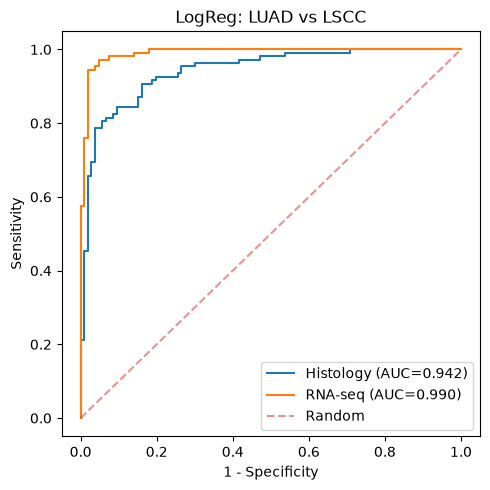

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

hist_fpr, hist_tpr, _ = roc_curve(y_true=y_hist_test, y_score=y_hist_prob[:, 1])
hist_auc = roc_auc_score(y_true=y_hist_test, y_score=y_hist_prob[:, 1])

expr_fpr, expr_tpr, _ = roc_curve(y_true=y_expr_test, y_score=y_expr_prob[:, 1])
expr_auc = roc_auc_score(y_true=y_expr_test, y_score=y_expr_prob[:, 1])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(hist_fpr, hist_tpr, label=f"Histology (AUC={hist_auc:0.3f})")
ax.plot(expr_fpr, expr_tpr, label=f"RNA-seq (AUC={expr_auc:0.3f})")
ax.plot([0, 1], [0, 1], label="Random", linestyle="--", color="tab:red", alpha=0.5)
ax.legend()
ax.set(xlabel="1 - Specificity", ylabel="Sensitivity", title="LogReg: LUAD vs LSCC")
fig.tight_layout()

## k-Nearest Neighbors (kNN)

We can rely on the built-in similarity search functionality of the embedding service to do neighborhood-based classification, without needing to bulk load everything.

In [4]:
# TODO replace me with similarity search from embedding service for TCGA and bulk load for CPTAC
import h5py
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def make_split_data(
    cohorts: dict[str, int],
    *,
    mode: str,
    agg_case: bool = False,
) -> tuple[
    np.ndarray, # X
    np.ndarray, # y
    pd.DataFrame, # metadata
]:
    # cohorts should be cohort name to categorical index
    # manually align cohorts across splits (e.g. TCGA-LUSC and CPTAC-LSCC)

    meta = []
    X = []
    for cohort in cohorts:
        with h5py.File(f"../embeddings/{mode}/{cohort}.h5", "r") as h5:
            for case_id in h5:
                case_group = h5[case_id]
                if agg_case:
                    case_X = []
                    for file_id in case_group:
                        case_X.append(case_group[file_id][:])
                    X.append(np.mean(case_X, axis=0))
                    meta.append({"case_id": case_id, "file_id": "agg", "cohort": cohort})
                else:
                    for file_id in case_group:
                        X.append(case_group[file_id][:])
                        meta.append({"case_id": case_id, "file_id": file_id, "cohort": cohort})
    meta = pd.DataFrame(meta)
    X = np.stack(X)

    meta = meta.sort_values(["case_id", "file_id"])
    X = X[meta.index.to_numpy()]

    meta = meta.reset_index(drop=True)
    return X, np.asarray([cohorts[x] for x in meta["cohort"]]), meta

X_hist_train, y_hist_train, hist_train_df = make_split_data({"TCGA-LUAD": 0, "TCGA-LUSC": 1}, mode="WSIs")
X_expr_train, y_expr_train, expr_train_df = make_split_data({"TCGA-LUAD": 0, "TCGA-LUSC": 1}, mode="RNAseq")

X_hist_test, y_hist_test, hist_test_df = make_split_data({"CPTAC-LUAD": 0, "CPTAC-LSCC": 1}, mode="WSIs", agg_case=True)
X_expr_test, y_expr_test, expr_test_df = make_split_data({"CPTAC-LUAD": 0, "CPTAC-LSCC": 1}, mode="RNAseq", agg_case=True)

# ensure we only consider test data with same cases across modalities
# test data is unique by case and sorted by case, so just filter to achieve same cases/ordering across modalities
test_case_ids = set(expr_test_df["case_id"]) & set(hist_test_df["case_id"])
hist_test_mask = hist_test_df["case_id"].isin(test_case_ids).to_numpy()
X_hist_test, y_hist_test = X_hist_test[hist_test_mask], y_hist_test[hist_test_mask]
expr_test_mask = expr_test_df["case_id"].isin(test_case_ids).to_numpy()
X_expr_test, y_expr_test = X_expr_test[expr_test_mask], y_expr_test[expr_test_mask]
assert (y_hist_test == y_expr_test).all()

def similarity_search(x: np.ndarray, modality: str, *, k: int) -> tuple[np.ndarray, np.ndarray]:
    if x.ndim == 1:
        x = x[np.newaxis, :] # (1, H)
    assert x.ndim == 2
    if modality == "hist":
        X_train, y_train = X_hist_train, y_hist_train
    elif modality == "expr":
        X_train, y_train = X_expr_train, y_expr_train
    else:
        raise ValueError(f"Unknown modality: {modality}")
    sims = cosine_similarity(X_train, x).squeeze() # (N_train)
    top_k_idxs = np.argsort(sims)[::-1][:k]
    return X_train[top_k_idxs], y_train[top_k_idxs]

In [5]:
import numpy as np
from sklearn.metrics import roc_auc_score

ks = [1, 2, 3, 5, 10, 25]
hist_aucs = []
expr_aucs = []
for modality, X_test, y_test, aucs in [
    ["hist", X_hist_test, y_hist_test, hist_aucs],
    ["expr", X_expr_test, y_expr_test, expr_aucs],
]:
    for k in ks:
        y_probs = []
        for x in X_test:
            _, y_sim = similarity_search(x, modality=modality, k=k)
            y_probs.append(y_sim.mean()) # use mean class of neighborhood as predicted prob
        y_probs = np.asarray(y_probs)
        auc = roc_auc_score(y_true=y_test, y_score=y_probs)
        aucs.append(auc)

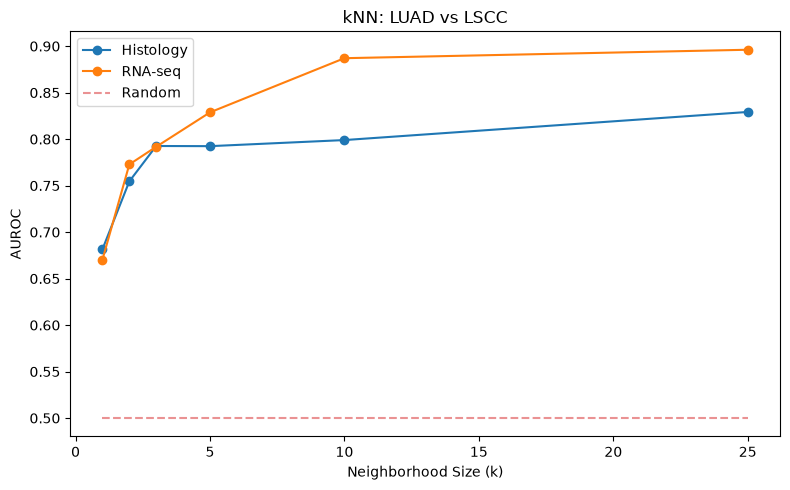

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, hist_aucs, label=f"Histology", marker="o")
ax.plot(ks, expr_aucs, label=f"RNA-seq", marker="o")
ax.plot(ks, [0.5] * len(ks), label=f"Random", color="tab:red", alpha=0.5, linestyle="--")
ax.legend()
ax.set(xlabel="Neighborhood Size (k)", ylabel="AUROC", title="kNN: LUAD vs LSCC")
fig.tight_layout()